In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Sampler, BatchSampler, Dataset, DataLoader, Subset, SubsetRandomSampler, random_split
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from matplotlib import pyplot as plt
import lmfit
from scipy import interpolate
from scipy import stats
import h5py
import pandas as pd
#import tables

(29304, 11) (29304, 6) (29304, 8) (228694, 11)


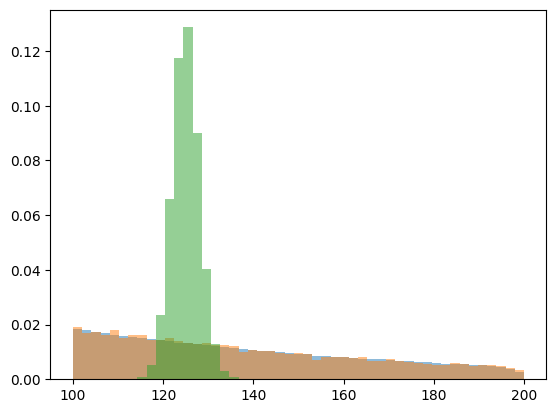

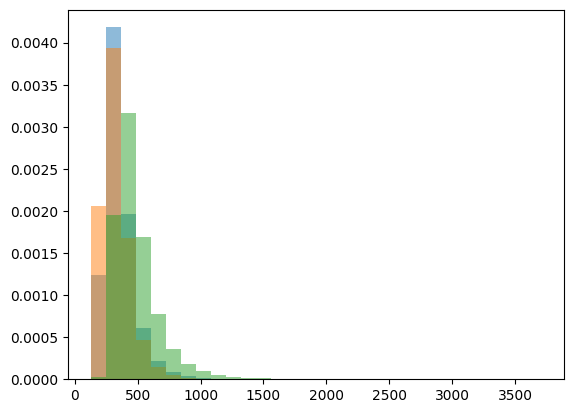

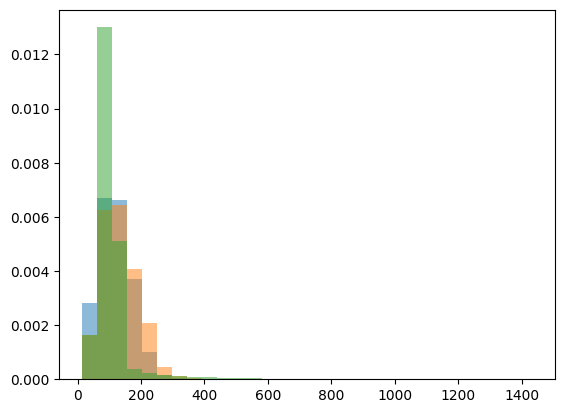

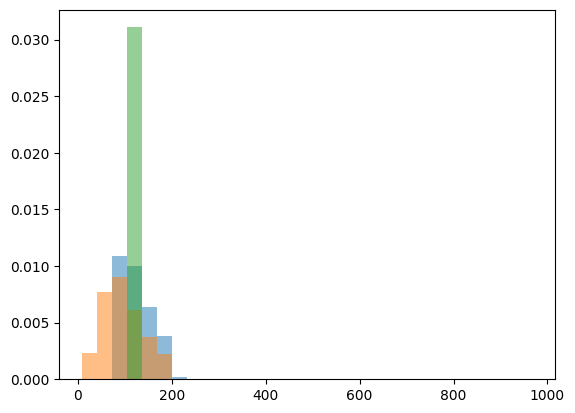

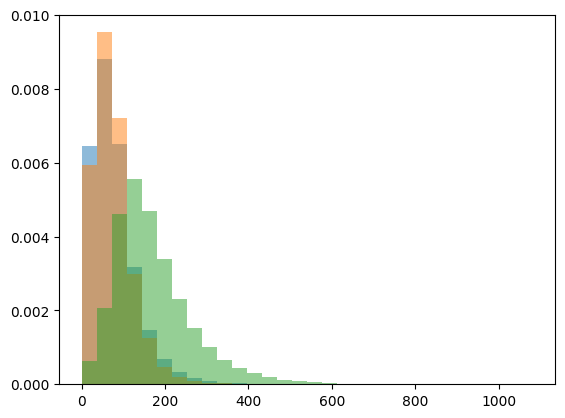

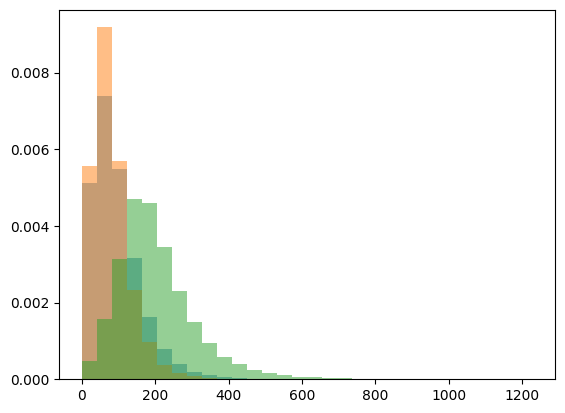

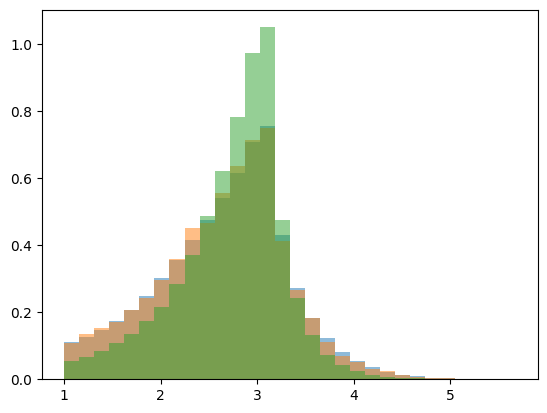

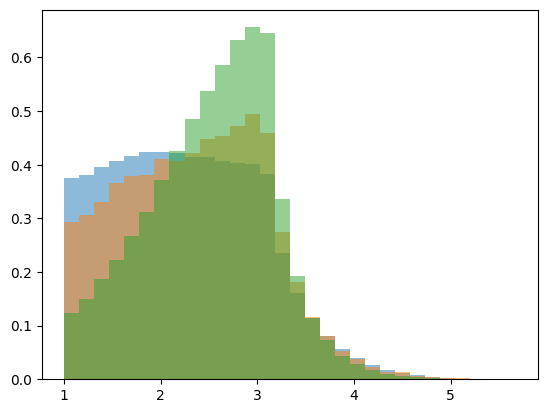

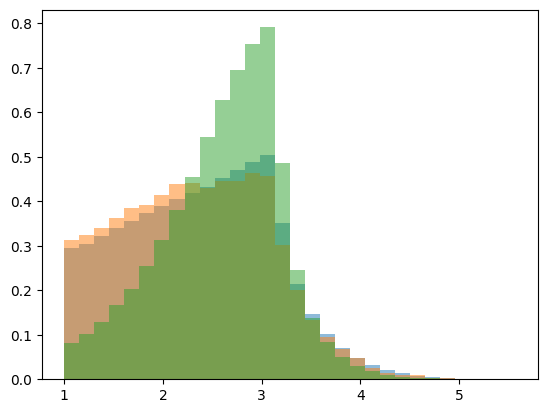

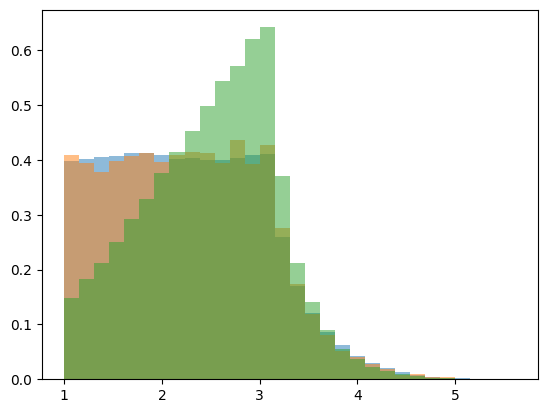

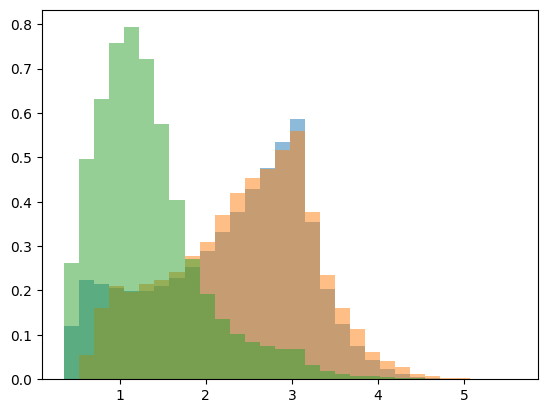

In [31]:
f_qcd0='data/bkg_bb_aa.h5'
f_qcd1='data/bkg_bb_aa_v2.h5'
f_hh1='data/sm_dihiggs.h5'
f_qcd_mc = h5py.File(f_qcd0,'r')
f_qcd_da = h5py.File(f_qcd1,'r')
f_hh  = h5py.File(f_hh1,'r')
print(f_qcd['feats'].shape,f_qcd['photons'].shape,f_qcd['bjets'].shape,f_hh['feats'].shape)
#print(f_qcd['bjets'][0,:])

bins=np.linspace(100,200,50)
plt.hist(f_qcd_mc['feats'][:,2],bins=bins,alpha=0.5,density=True)
plt.hist(f_qcd_da['feats'][:,2],bins=bins,alpha=0.5,density=True)
plt.hist(f_hh['feats'][:,2],bins=bins,alpha=0.5,density=True)
plt.show()

def convert(iData):
    cols = [f"dog_{i}" for i in range(iData.shape[1])]
    dfs = pd.DataFrame(iData, columns=cols)
    cols = ["dog_0","dog_1","dog_3","dog_4","dog_5","dog_6","dog_7","dog_8","dog_9","dog_10","dog_2"]
    dfs=dfs.reindex(columns=cols)
    return dfs
hh_data  = convert(f_hh['feats'])
qcd_data = convert(f_qcd_da['feats'])
qcd_mc   = convert(f_qcd_mc['feats'])

def plotHist(iFeat):
    counts, bin_edges, patches = plt.hist(f_qcd_mc['feats'][:,i0],bins=30,alpha=0.5,density=True)
    plt.hist(f_qcd_da['feats'][:,i0],bins=bin_edges,alpha=0.5,density=True)
    plt.hist(f_hh['feats'][:,i0],bins=bin_edges,alpha=0.5,density=True)
    plt.show()

for i0 in range(10):
    plotHist(i0)

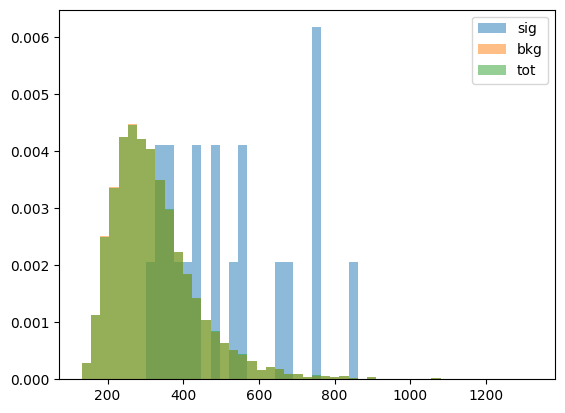

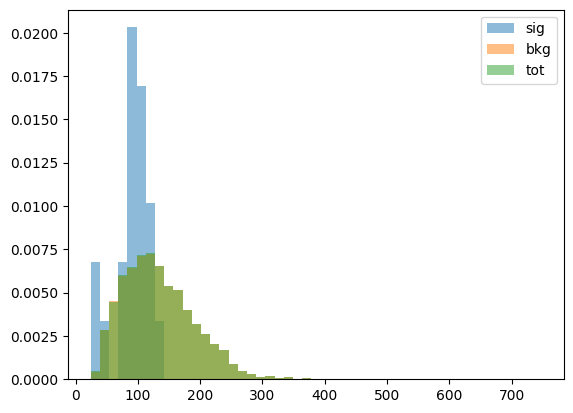

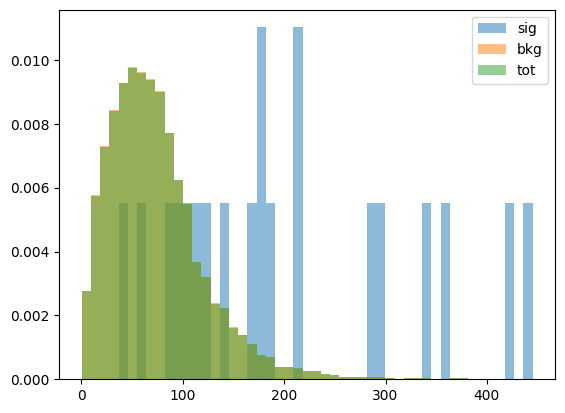

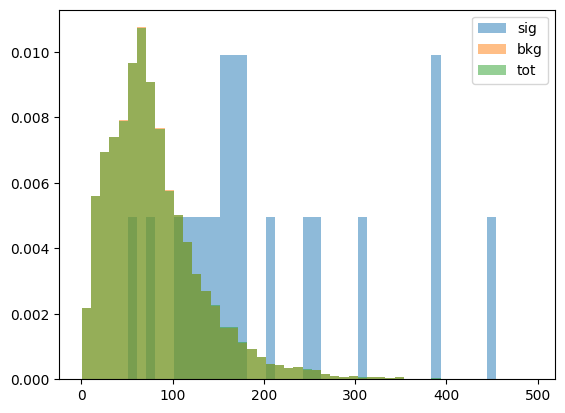

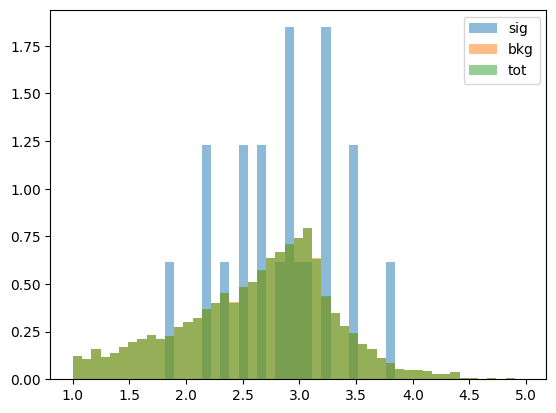

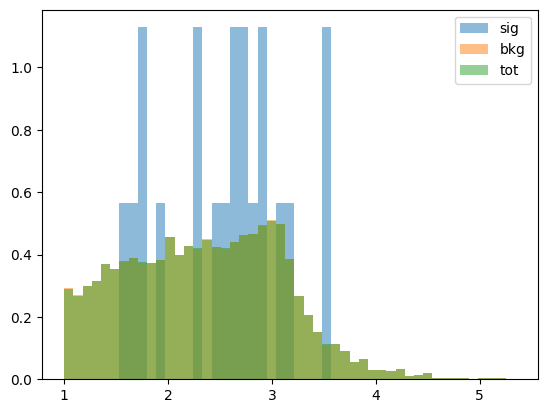

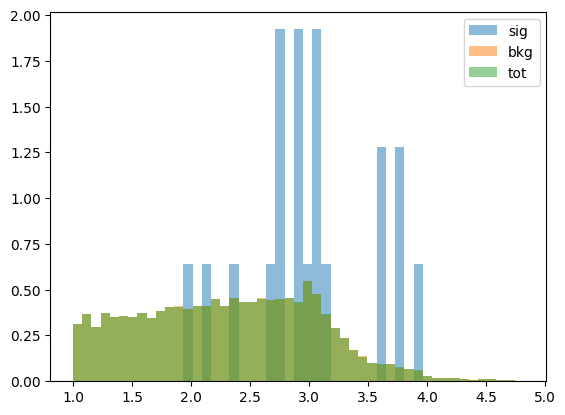

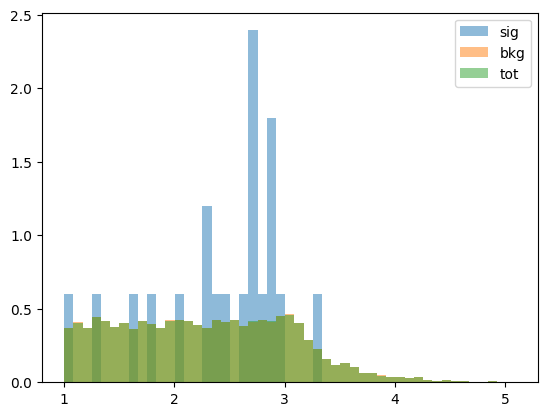

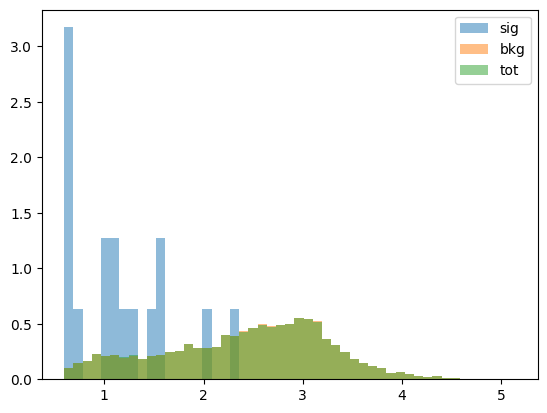

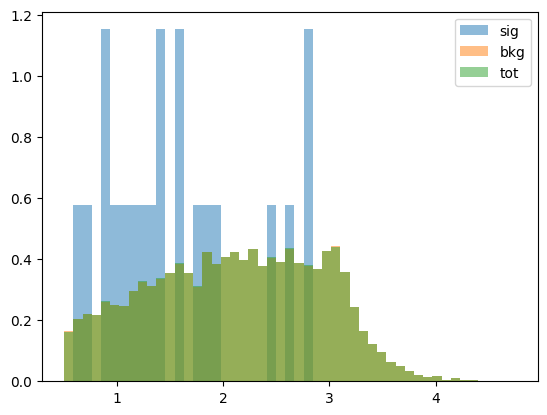

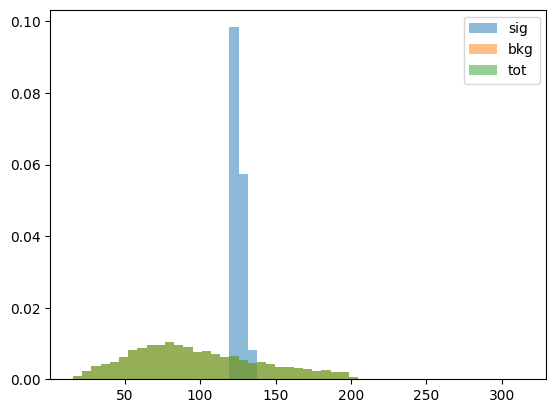

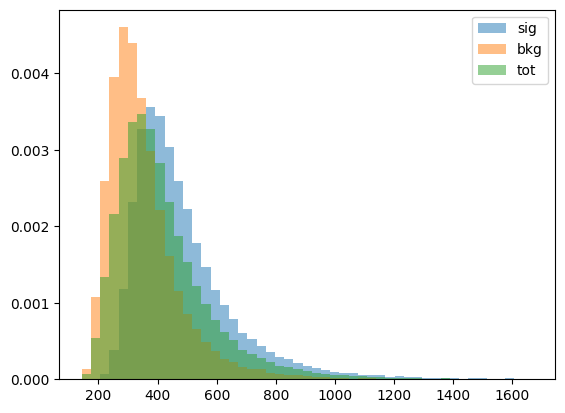

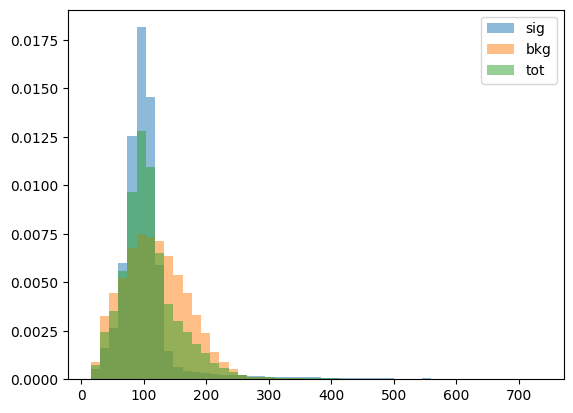

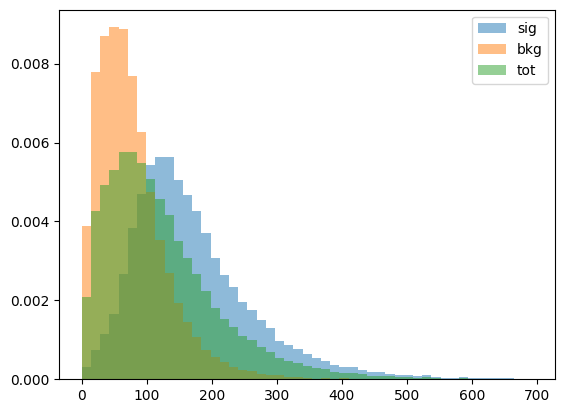

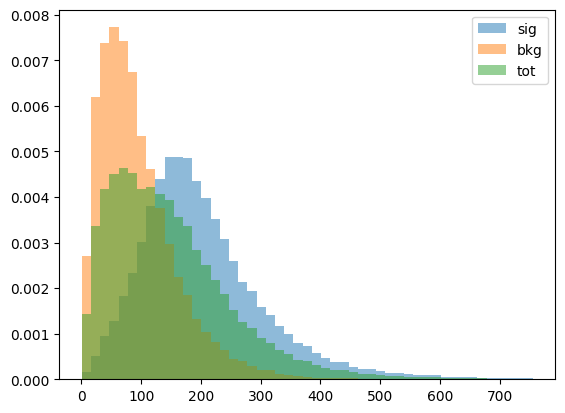

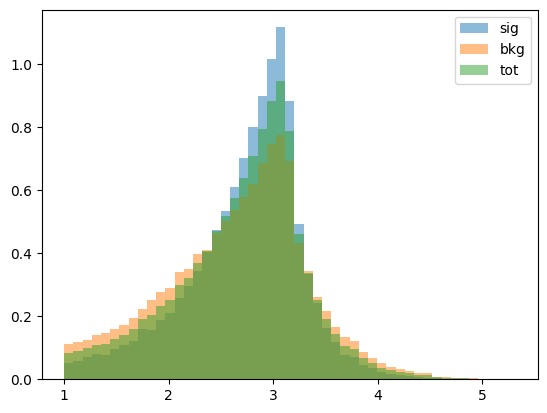

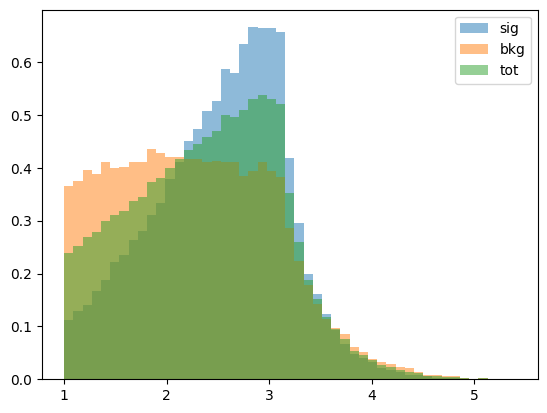

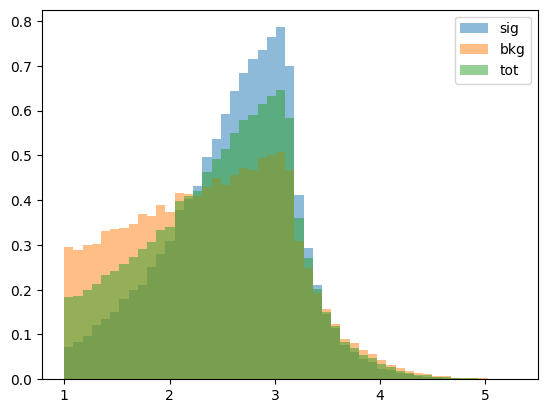

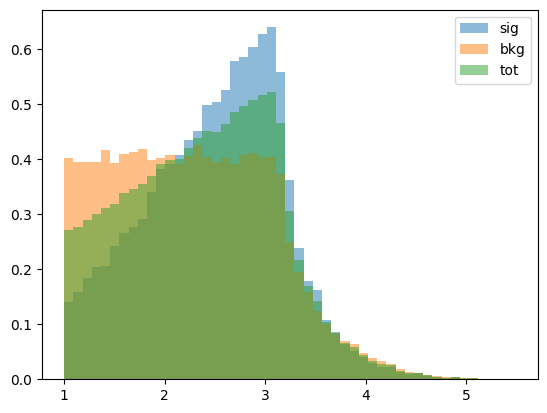

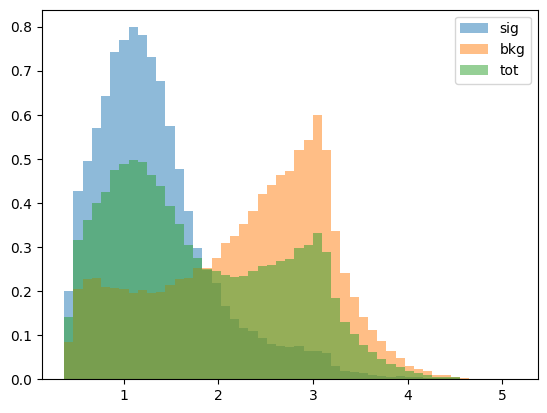

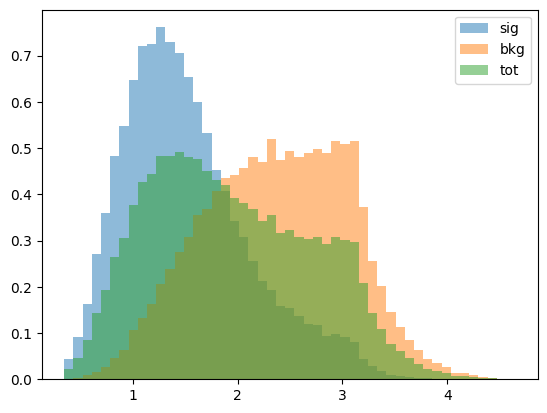

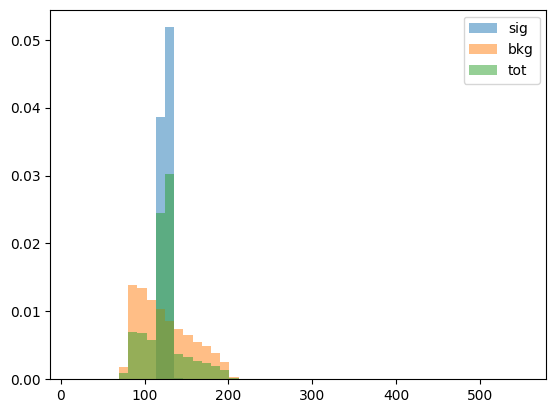

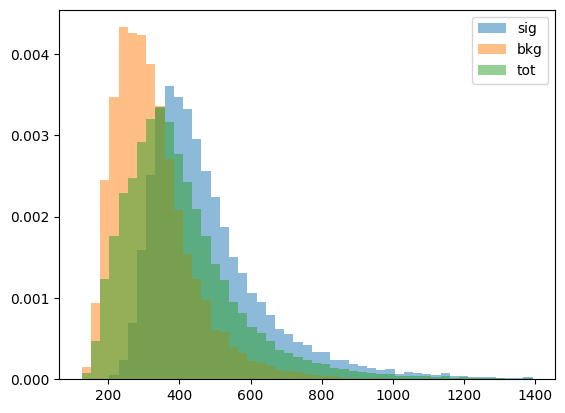

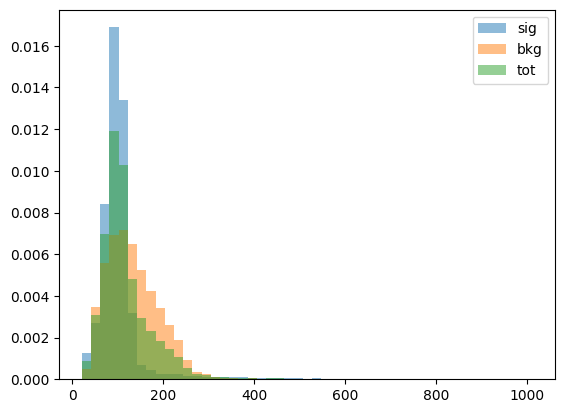

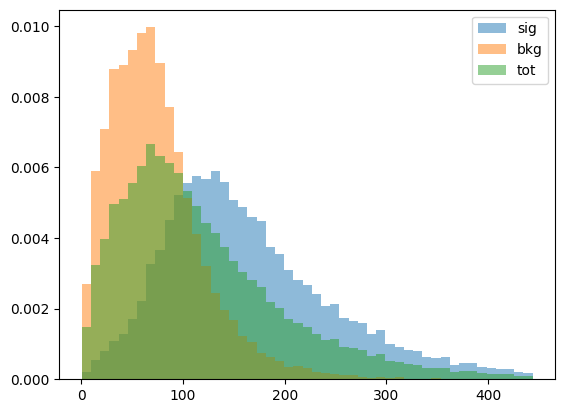

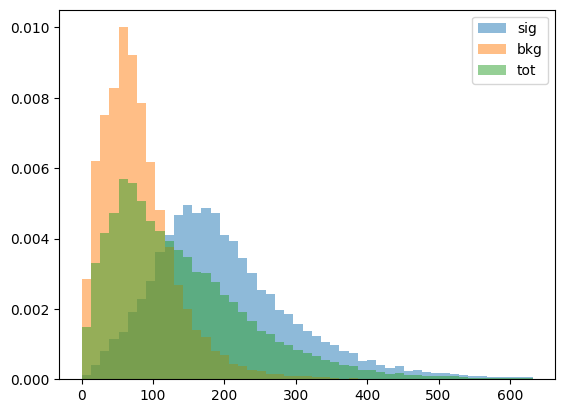

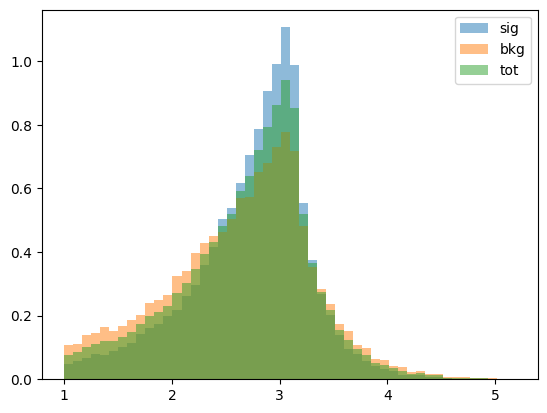

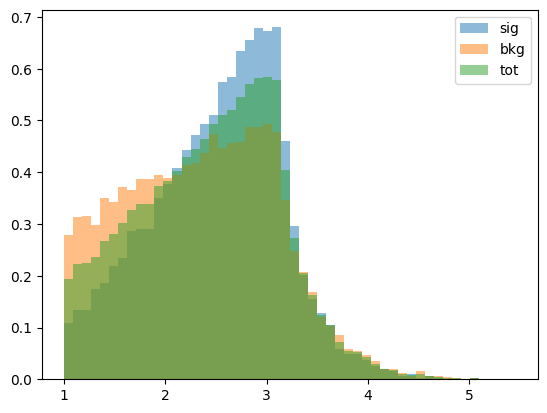

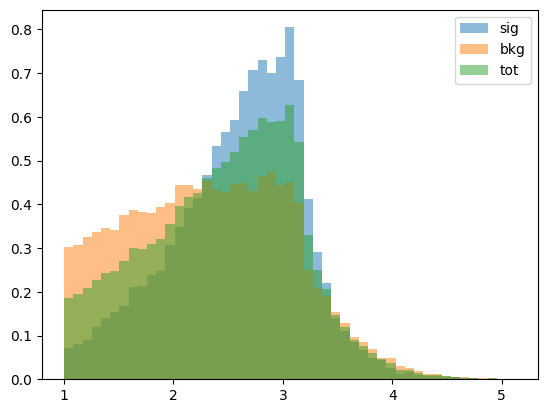

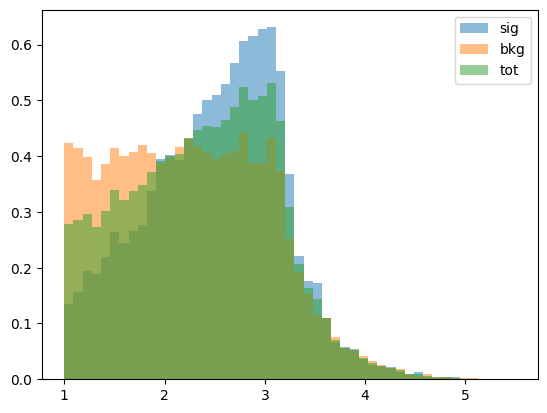

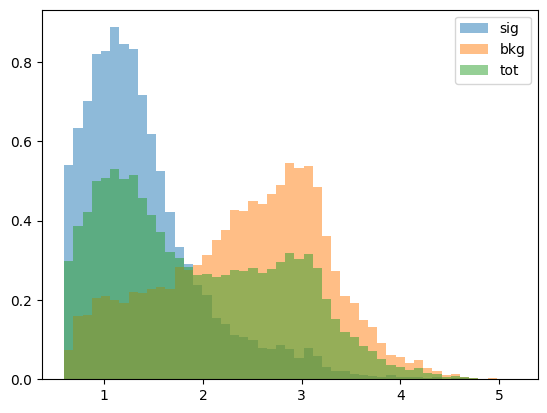

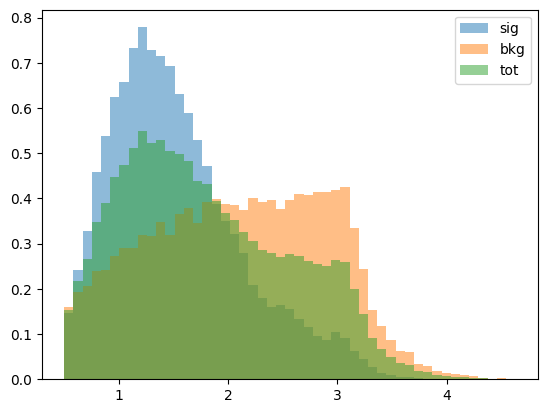

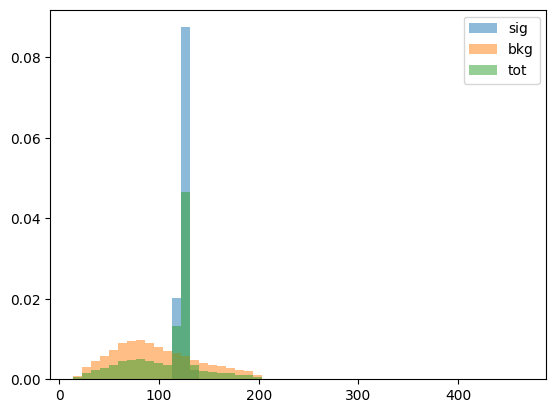

7020 100000


In [44]:
class DataSet(Dataset):
    def __init__(self, samples, labels, disc):
        super(DataSet, self).__init__()
        self.labels  = labels
        self.samples = samples
        self.disc    = disc
        if len(samples) != len(labels):
            raise ValueError(
                f"should have the same number of samples({len(samples)}) as there are labels({len(labels)})")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        y = self.labels[index]
        x = self.samples[index]
        z = self.disc[index]
        return x, y, z 
    
def mass(iDS): 
    e12   = np.sqrt(iDS.pxj1**2 + iDS.pyj1**2 + iDS.pzj1**2 + iDS.mj1**2)
    e22   = np.sqrt(iDS.pxj2**2 + iDS.pyj2**2 + iDS.pzj2**2 + iDS.mj2**2)
    etot  = e12 + e22
    pxtot = iDS.pxj1 + iDS.pxj2
    pytot = iDS.pyj1 + iDS.pyj2
    pztot = iDS.pzj1 + iDS.pzj2
    return np.sqrt(etot**2 - pxtot**2 - pytot**2 - pztot**2)

def makeNP(iDS):
    massvals=mass(iDS)
    tmp=iDS[["mj1","tau1j1","tau2j1","tau3j1","mj2","tau1j2","tau2j2","tau3j2"]].to_numpy()
    massvals=np.reshape(massvals,(len(massvals),1))
    tmp=np.hstack((tmp,massvals))
    print(len(tmp))
    return tmp

def makeDataSet(iD,iNS,iNB):
    pD    = torch.from_numpy(iD)
    discs = torch.cat((torch.ones(iNS), torch.zeros(iNB)))
    rand  = torch.randperm(len(pD))
    pXD   = pD[rand]
    tot   = pXD[:,:-1].float()   #this is our discriminator we want to learn
    label = pXD[:,-1].float()  ####Note this is a regression, so we want to put y=f(x)
    xdisc = discs[rand]
    datatrain=DataSet(samples=tot,labels=label, disc=xdisc)
    bkgdatatrain=DataSet(samples=pD[iNS:,:-1].float(),labels=pD[iNS:,-1].float(),disc=torch.zeros(iNB))
    return datatrain,bkgdatatrain,pD[0:iNS].float(),pD[iNS:].float()

def plotSigBkg(iN,sig,bkg,nbins=50):
    tot=torch.cat((sig,bkg))
    for pVar in range(iN+2):
        xmin=torch.min(bkg[:,pVar])
        xmax=torch.max(bkg[:,pVar])
        binrange=np.arange(xmin,xmax,(xmax-xmin)/nbins)
        plt.hist(sig[:,pVar],bins=binrange,density=True,alpha=0.5,label='sig')
        plt.hist(bkg[:,pVar],bins=binrange,density=True,alpha=0.5,label='bkg')
        plt.hist(tot[:,pVar],bins=binrange,density=True,alpha=0.5,label='tot')
        plt.legend()
        plt.show()

def setupData(iParr1,iParr2,iNB,iNS,iStart=0,iSStart=0):
    nparr1=iParr1[iStart:(iStart+iNB)]
    nparr2=iParr2[iSStart:(iSStart+iNS)]
    pdata = np.vstack((nparr2,nparr1))
    data,bkgdata,test_sig,test_bkg=makeDataSet(pdata,len(nparr2),len(nparr1))
    plotSigBkg(9,test_sig,test_bkg)
    return data,bkgdata,test_sig,test_bkg

#massvec1 = mass(df1)
#massvec2 = mass(df2)
#bins=np.arange(2000,8000,20)
#plt.hist(massvec1,bins=bins,alpha=0.5)
#plt.hist(massvec2,bins=bins,alpha=0.5)
#plt.show()
dataset,mcdataset,sig,bkg    =setupData(qcd_data,hh_data,7000,20) #3ab yield
dataset2,mcdataset2,sig2,bkg2=setupData(qcd_mc  ,hh_data,50000,50000,10000,1000)
dataset3,mcdataset3,sig3,bkg3=setupData(qcd_data,hh_data,20000,20000,8000,1000)
print(len(dataset),len(dataset2))

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 29
    # data points      = 40
    # variables        = 3
    chi-square         = 30.5995413
    reduced chi-square = 0.82701463
    Akaike info crit   = -4.71577739
    Bayesian info crit = 0.35086098
    R-squared          = 0.99517062
[[Variables]]
    par0:  151.311802 +/- 29.8448120 (19.72%) (init = 0.1)
    par1: -1.19464750 +/- 0.47644623 (39.88%) (init = 0)
    par2:  0.00241086 +/- 0.00186556 (77.38%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(par1, par2) = -0.998
    C(par0, par1) = -0.997
    C(par0, par2) = 0.989
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 16
    # data points      = 40
    # variables        = 4
    chi-square         = 29.2161988
    reduced chi-square = 0.81156108
    Akaike info crit   = -4.56624575
    Bayesian info crit = 2.18927207
    R-squared          = 0.99538895
[[Variables]]
    par0:  163.820967 +/- 31.078

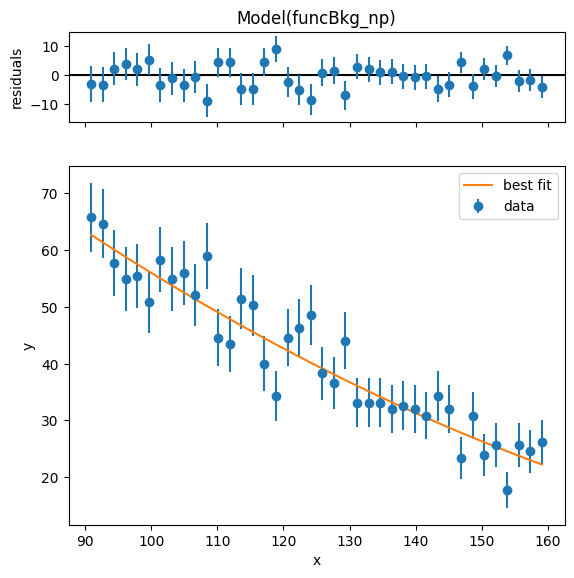

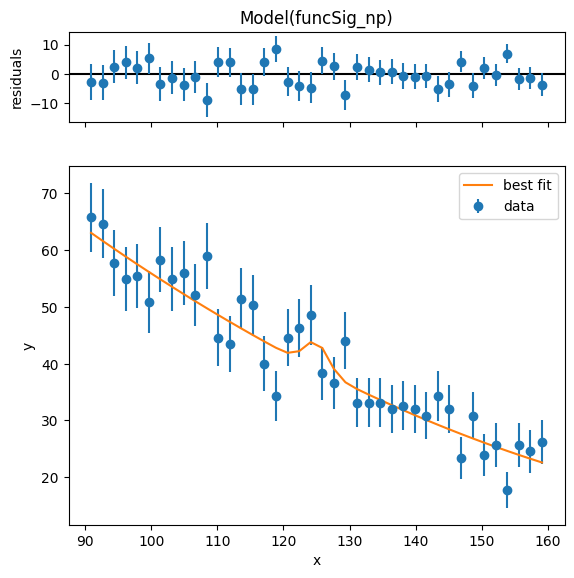

In [36]:
#%load_ext autoreload
%reload_ext autoreload
%autoreload 2
from splitfitter import fitGausBern


nbins=40
xmax=160
xmin=90
delta      = (xmax - xmin) / nbins
BIN_Table  = torch.arange(start=0, end=nbins+1, step=1) * delta +xmin
h_r        = 0.5*(BIN_Table[1:] + BIN_Table[:-1])
input=torch.cat((sig[:,-1],bkg[:,-1]))
h_r        = 0.5*(BIN_Table[1:] + BIN_Table[:-1])
input=torch.cat((sig[:,-1],bkg[:,-1]))
tmp=fitGausBern()
yhist,xbins=torch.histogram(input,BIN_Table,density=False)
yerr=((torch.sqrt(yhist))/delta).detach().numpy()
ytmp=(yhist*1./delta).detach().numpy()
xtmp=h_r.detach().numpy()
#plt.plot(xtmp,yhist)
#plt.show()
#print(ytmp)
_,result,_=tmp.fitBkg(xtmp,ytmp,yerr)
print(result)
result.plot()
lmfit.report_fit(result)

_,result,_=tmp.fitSig(xtmp,ytmp,yerr)
result.plot()
lmfit.report_fit(result)

In [41]:
%load_ext autoreload
%autoreload 2
from splitfitter import simple_MLPFit_lmfit,fitGausLin,fitGausPowLaw,fitGausFlat,fitGausDijet,fitGausBern,plotPerf,plotCheck

rw_model = simple_MLPFit_lmfit(dataset,10,k_fold=2,nhidden=32,out_channels=1,act_out=False,n_epochs=1,fit_opt=2,bkg_loss=1.5,iFitPFunc=fitGausBern(),iFitFFunc=fitGausBern(),
                                massDeco=0.,mc_data=mcdataset,bkgPressure=True,lambScale=0.0,batch_size=7020,lambvar=0.)

print(len(dataset2))
rw_model.pretrain(dataset2,1000,50)
rw_model.train(10)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
100000
Epoch: 0 LOSS train: 317.3673095703125 
Epoch: 10 LOSS train: 37.76176071166992 
Epoch: 20 LOSS train: 37.03388977050781 
Epoch: 30 LOSS train: 35.78599166870117 
Epoch: 40 LOSS train: 34.680213928222656 
Epoch: 0 LOSS train: 195.90428161621094 
Epoch: 10 LOSS train: 38.17635726928711 
Epoch: 20 LOSS train: 36.102134704589844 
Epoch: 30 LOSS train: 35.535282135009766 
Epoch: 40 LOSS train: 35.125404357910156 
K-fold 0
Epoch: 0 LOSS train: -0.8722798824310303 Pars 1: -1.5115923606892352 - 2: 0.2552070178248904 deco: 0
Epoch: 1 LOSS train: -2.5288476943969727 Pars 1: -2.9815675886271116 - 2: 0.1803951290068646 deco: 0
Epoch: 2 LOSS train: -2.5659327507019043 Pars 1: -3.048596930105914 - 2: 0.20655267418592516 deco: 0
Epoch: 3 LOSS train: -2.868041515350342 Pars 1: -3.278645767498773 - 2: 0.15729054996268843 deco: 0
Epoch: 4 LOSS train: -3.569196939468384 Pars 1: -3.89786601029334 - 2: 0.1052417

In [47]:
rw_model = simple_MLPFit_lmfit(dataset,10,k_fold=2,nhidden=32,out_channels=1,act_out=False,n_epochs=1,fit_opt=2,bkg_loss=1.5,iFitPFunc=fitGausBern(),iFitFFunc=fitGausBern(),
                                massDeco=0.,mc_data=mcdataset,bkgPressure=True,lambScale=0.0,batch_size=7020,lambvar=0.)

rw_model.pretrain(dataset3,1000,50)
rw_model.train(20)


Epoch: 0 LOSS train: 114.81497955322266 
Epoch: 10 LOSS train: 13.141878128051758 
Epoch: 20 LOSS train: 12.14641284942627 
Epoch: 30 LOSS train: 11.661772727966309 
Epoch: 40 LOSS train: 11.456868171691895 
Epoch: 0 LOSS train: 424.1761169433594 
Epoch: 10 LOSS train: 12.653348922729492 
Epoch: 20 LOSS train: 12.26274299621582 
Epoch: 30 LOSS train: 11.903167724609375 
Epoch: 40 LOSS train: 11.882622718811035 
K-fold 0
Epoch: 0 LOSS train: 0.9137786626815796 Pars 1: -0.8836368249416875 - 2: 0.9265409462729295 deco: 0
Epoch: 1 LOSS train: 0.0007501840591430664 Pars 1: -1.5283024589876897 - 2: 0.8720018968105165 deco: 0
Epoch: 2 LOSS train: -1.0173381567001343 Pars 1: -2.3218794005250096 - 2: 0.7182625269312126 deco: 0
Epoch: 3 LOSS train: -1.1109576225280762 Pars 1: -2.464031436789732 - 2: 0.694797243334591 deco: 0
Epoch: 4 LOSS train: -1.5992755889892578 Pars 1: -2.7722668480295454 - 2: 0.5898358008257212 deco: 0
Epoch: 5 LOSS train: -1.864152193069458 Pars 1: -2.905758137617159 - 2: 

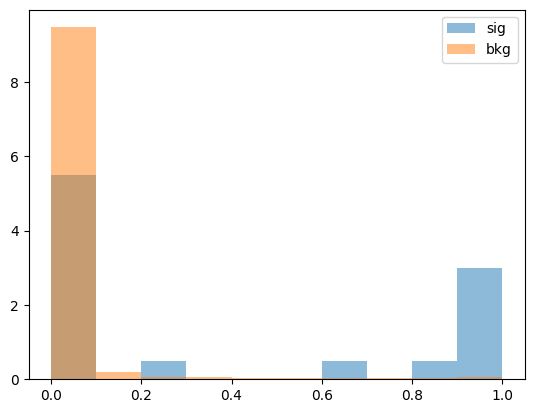

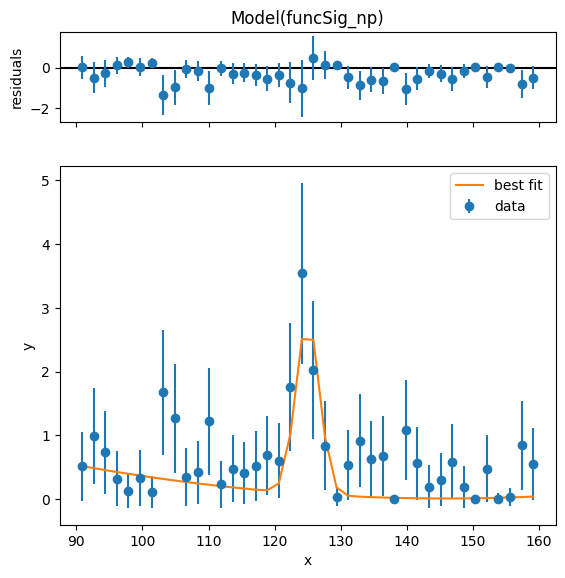

Pass Significance: 10.883990825868594
Fail Significance: 0.3917213749617403


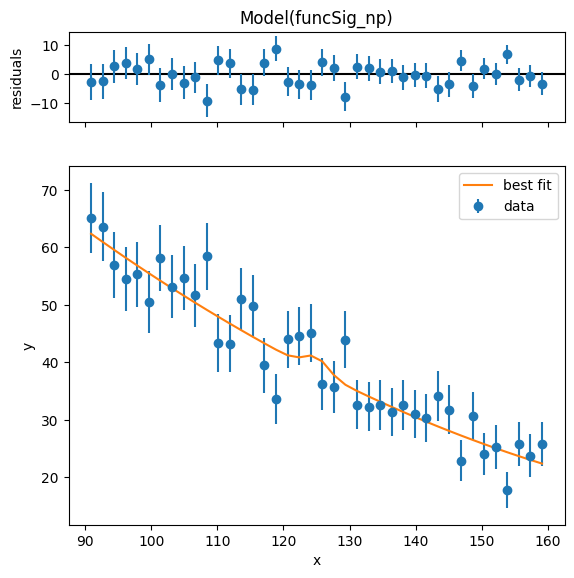

here!
torch.Size([7000, 1]) torch.Size([7000])
tensor([101.1338,  69.2160,  81.7647,  ...,  85.8496,  49.1674,  51.4697])
Bkg Significance: 5.016555901822773


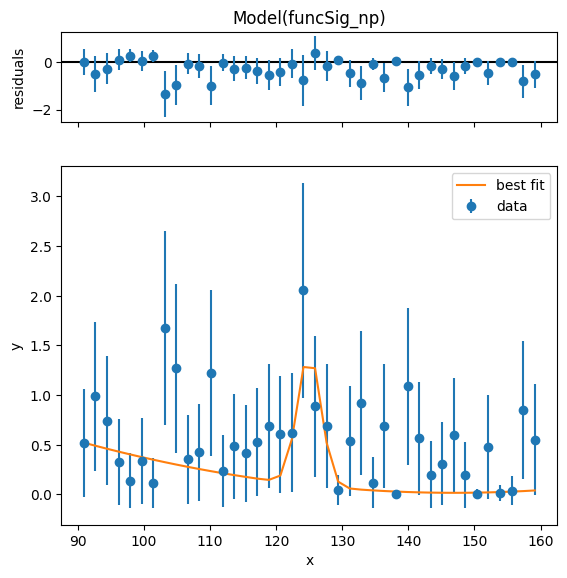

In [48]:
plotPerf(sig,bkg,rw_model)

Significance: 5.444004978137503


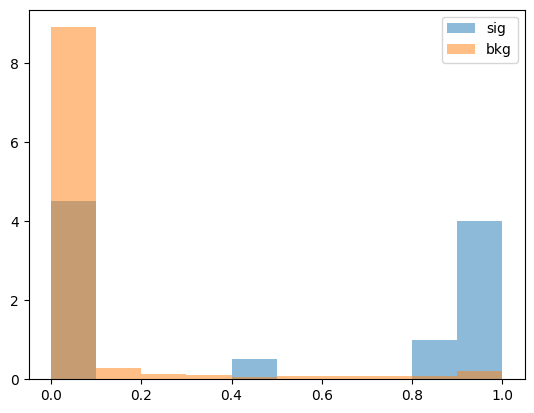

Over train Significance: 12.228779632482116


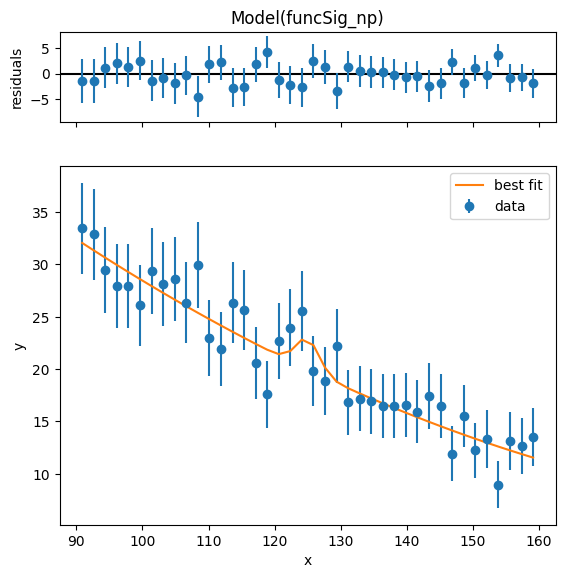

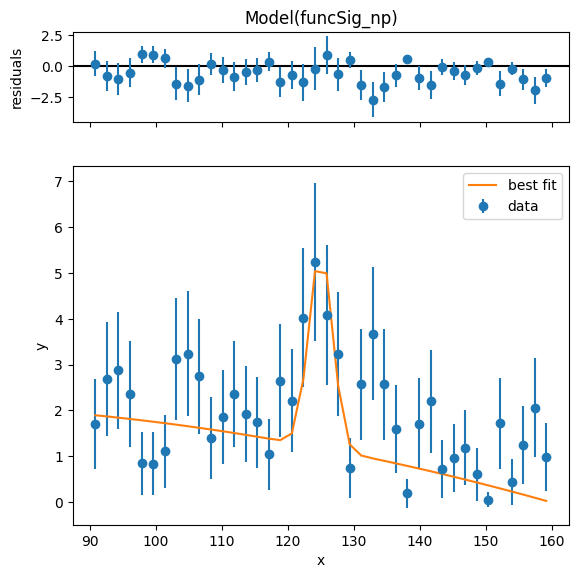

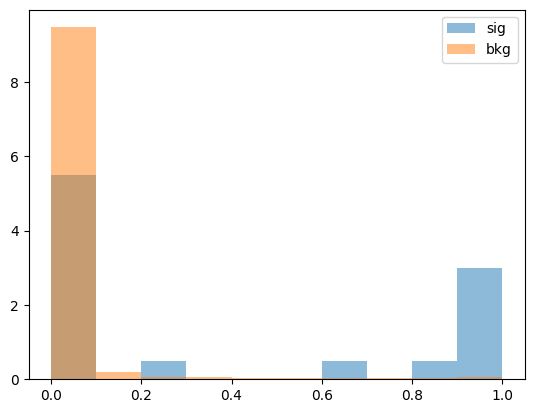

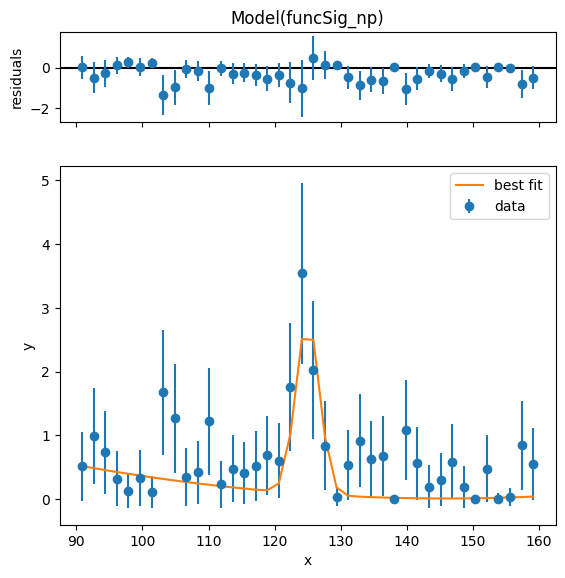

Pass Significance: 10.883990825868594
Fail Significance: 0.3917213749617403


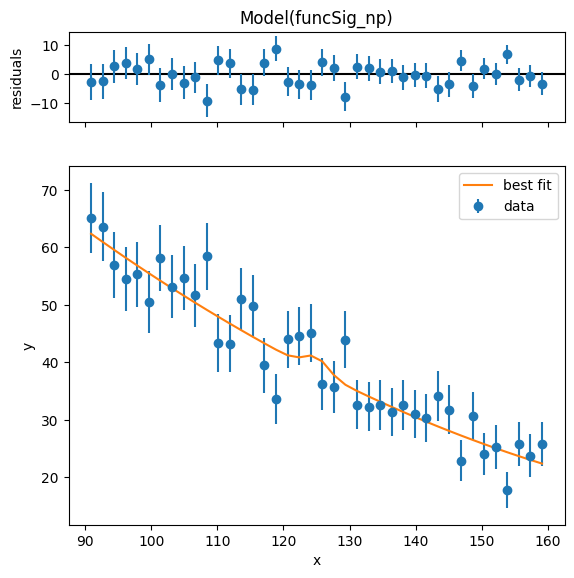

here!
torch.Size([7000, 1]) torch.Size([7000])
tensor([101.1338,  69.2160,  81.7647,  ...,  85.8496,  49.1674,  51.4697])
Bkg Significance: 5.016555901822773


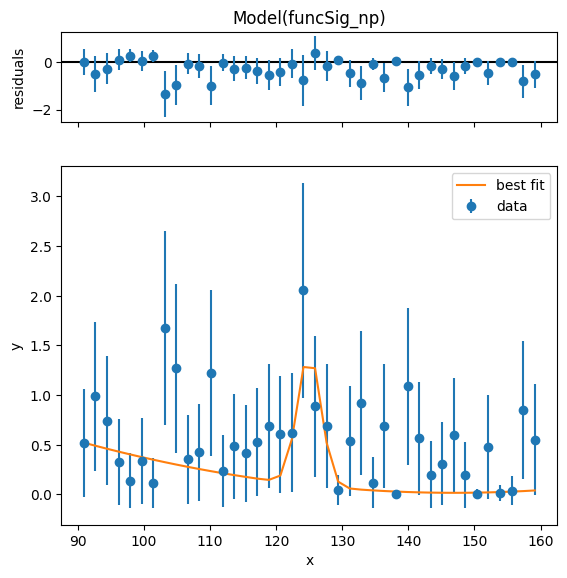

In [49]:
plotCheck(rw_model)
plotPerf(sig,bkg,rw_model)

In [51]:
rw_model_data = simple_MLPFit_lmfit(dataset,10,k_fold=2,nhidden=32,out_channels=1,act_out=False,n_epochs=1,fit_opt=2,bkg_loss=1.5,iFitPFunc=fitGausBern(),iFitFFunc=fitGausBern(),
                                massDeco=0.,mc_data=mcdataset,bkgPressure=True,lambScale=0.0,batch_size=7020,lambvar=0.)

rw_model_data.pretrain(dataset2,5000,50)
rw_model_data.train(20)


Epoch: 0 LOSS train: 38.05487823486328 
Epoch: 10 LOSS train: 8.49034309387207 
Epoch: 20 LOSS train: 7.737694263458252 
Epoch: 30 LOSS train: 7.47583532333374 
Epoch: 40 LOSS train: 7.356394290924072 
Epoch: 0 LOSS train: 272.7725524902344 
Epoch: 10 LOSS train: 8.619454383850098 
Epoch: 20 LOSS train: 7.751347064971924 
Epoch: 30 LOSS train: 7.539895057678223 
Epoch: 40 LOSS train: 7.448345184326172 
K-fold 0
Epoch: 0 LOSS train: 2.818828821182251 Pars 1: -0.31461973067972515 - 2: 1.6182403539328902 deco: 0
Epoch: 1 LOSS train: 0.9158141613006592 Pars 1: -1.0913773785672873 - 2: 1.1135932228913923 deco: 0
Epoch: 2 LOSS train: 0.3492870330810547 Pars 1: -1.3653421561201728 - 2: 0.9797467702897151 deco: 0
Epoch: 3 LOSS train: 0.4118947982788086 Pars 1: -1.258631921948652 - 2: 0.9627176818783241 deco: 0
Epoch: 4 LOSS train: 0.2901337146759033 Pars 1: -1.3181180107424542 - 2: 0.9243776861894055 deco: 0
Epoch: 5 LOSS train: -0.2654080390930176 Pars 1: -1.7929864656979362 - 2: 0.8712135211

Significance: 1.6360982540824622


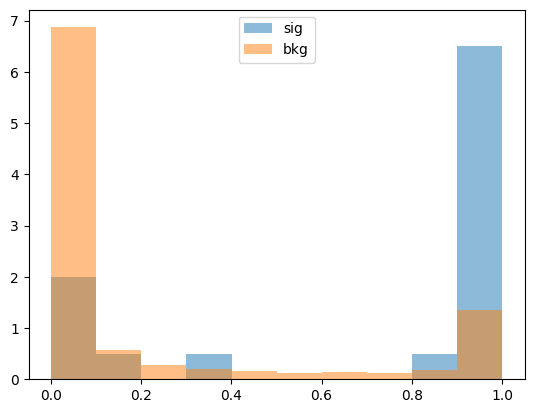

Over train Significance: 5.31799980414274


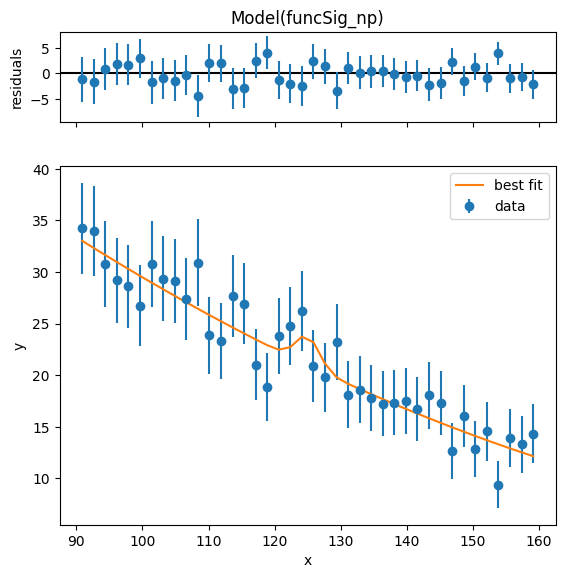

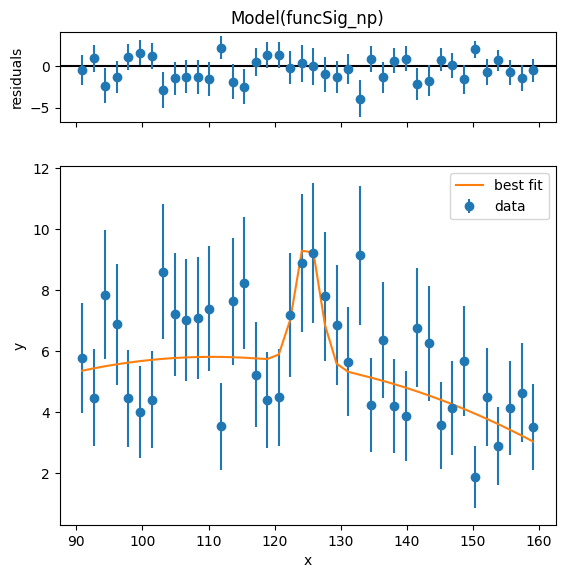

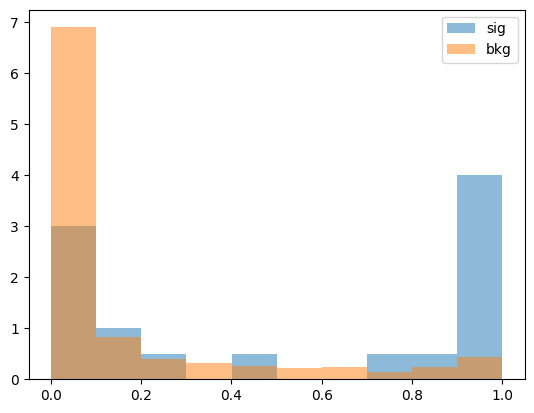

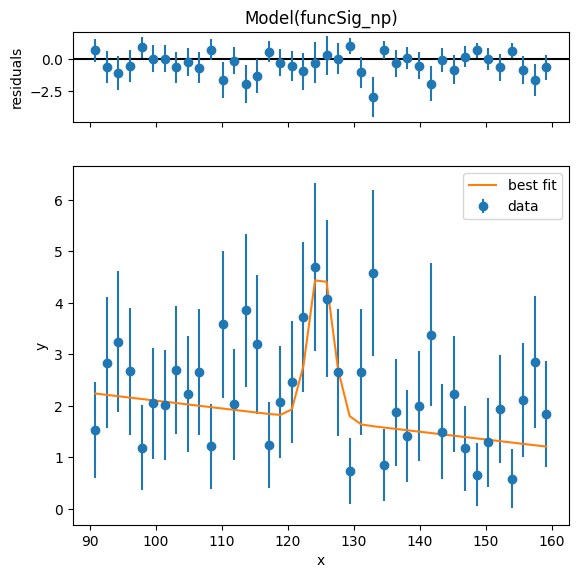

Pass Significance: 6.179236942001246
Fail Significance: 0.3907512220065783


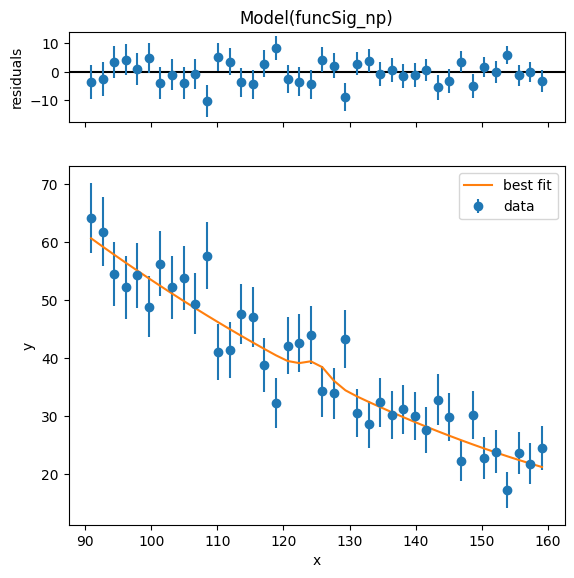

here!
torch.Size([7000, 1]) torch.Size([7000])
tensor([101.1338,  69.2160,  81.7647,  ...,  85.8496,  49.1674,  51.4697])
Bkg Significance: 0.7718043641452184


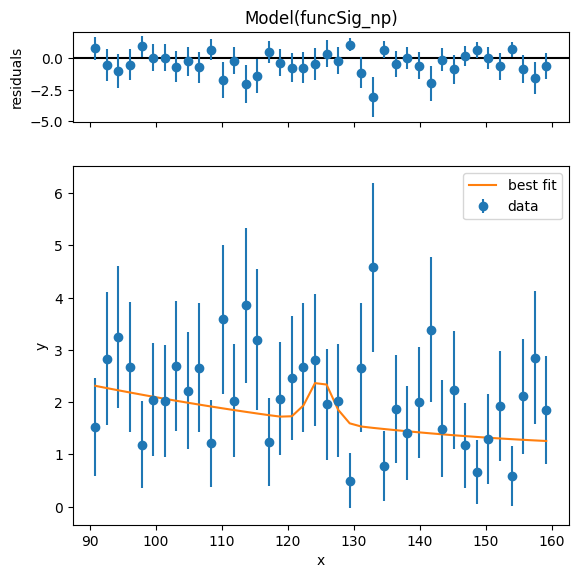

In [53]:
plotCheck(rw_model_data)
plotPerf(sig,bkg,rw_model_data)

In [55]:
rw_model_basic = simple_MLPFit_lmfit(dataset,10,k_fold=2,nhidden=32,out_channels=1,act_out=False,n_epochs=1,fit_opt=2,bkg_loss=1.5,iFitPFunc=fitGausBern(),iFitFFunc=fitGausBern(),
                                massDeco=0.,mc_data=mcdataset,bkgPressure=True,lambScale=0.0,batch_size=7020,lambvar=0.)

rw_model_basic.pretrain(dataset2,5000,50)
rw_model_basic.train(1)


Epoch: 0 LOSS train: 455.0745544433594 
Epoch: 10 LOSS train: 8.652759552001953 
Epoch: 20 LOSS train: 7.968193531036377 
Epoch: 30 LOSS train: 7.583427429199219 
Epoch: 40 LOSS train: 7.436563014984131 
Epoch: 0 LOSS train: 106.89102172851562 
Epoch: 10 LOSS train: 8.41595458984375 
Epoch: 20 LOSS train: 7.750152587890625 
Epoch: 30 LOSS train: 7.404797554016113 
Epoch: 40 LOSS train: 7.283085823059082 
K-fold 0
Epoch: 0 LOSS train: -0.4864490032196045 Pars 1: -1.3054959262101118 - 2: 0.33781261612129754 deco: 0
K-fold 1
Epoch: 0 LOSS train: 0.23405006527900696 Pars 1: -0.11490252527571343 - 2: 0.09080613972699325 deco: 0


Significance: 0.6974041293334814


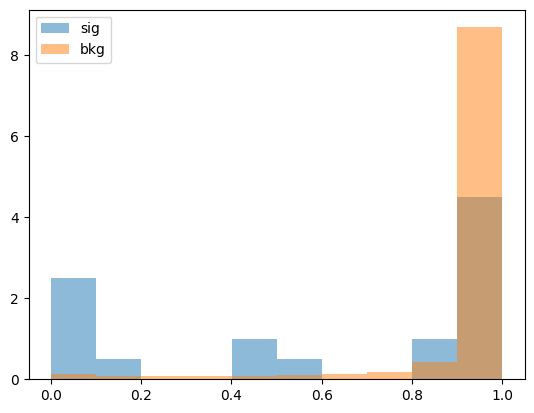

Over train Significance: 1.0838101876779014


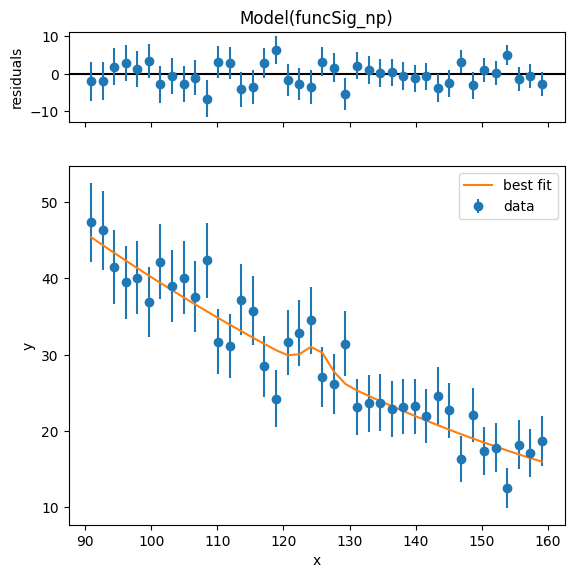

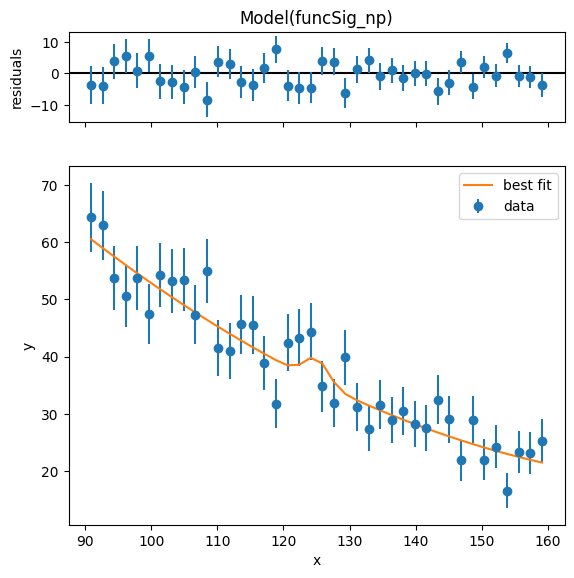

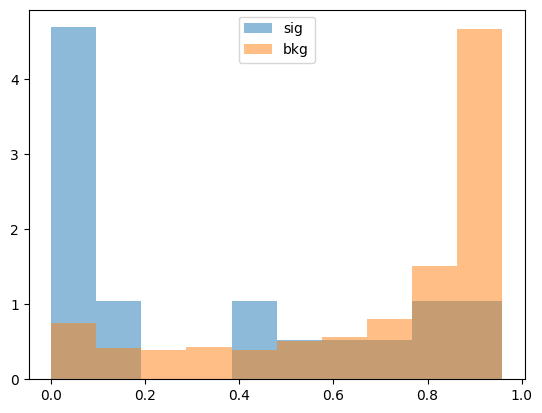

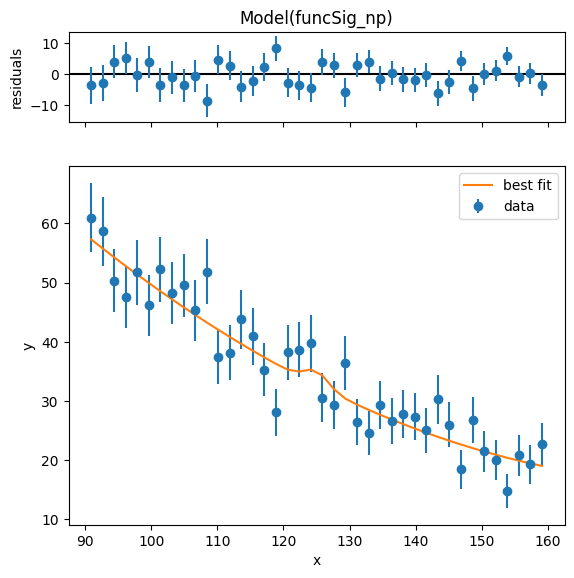

Pass Significance: 0.45090173636871
Fail Significance: 2.42958752816509


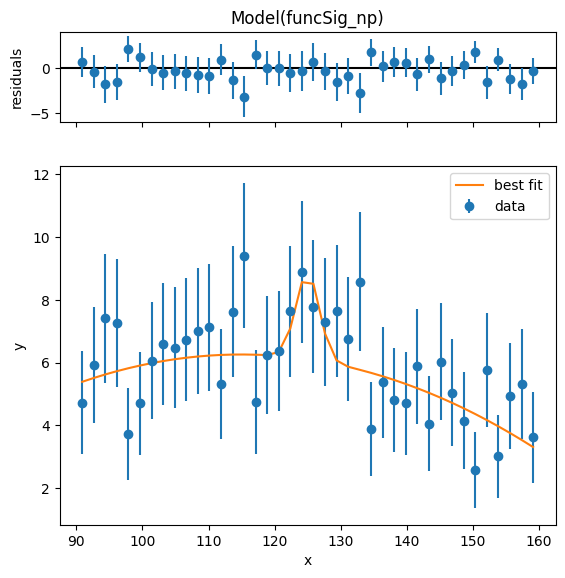

here!
torch.Size([7000, 1]) torch.Size([7000])
tensor([101.1338,  69.2160,  81.7647,  ...,  85.8496,  49.1674,  51.4697])
Bkg Significance: 0.1008065773969804


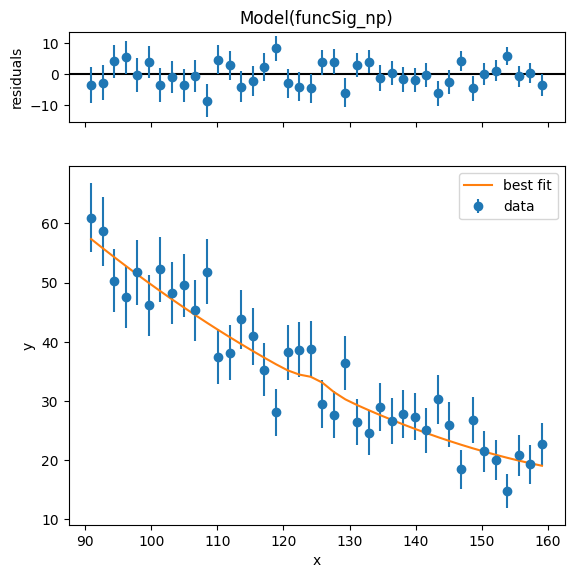

In [56]:
plotCheck(rw_model_data)
plotPerf(sig,bkg,rw_model_data)

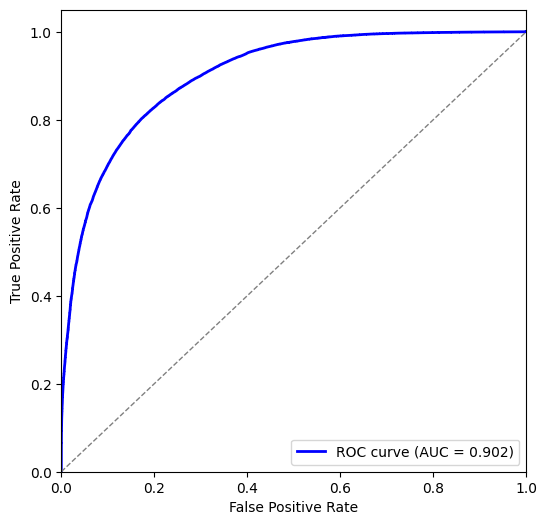

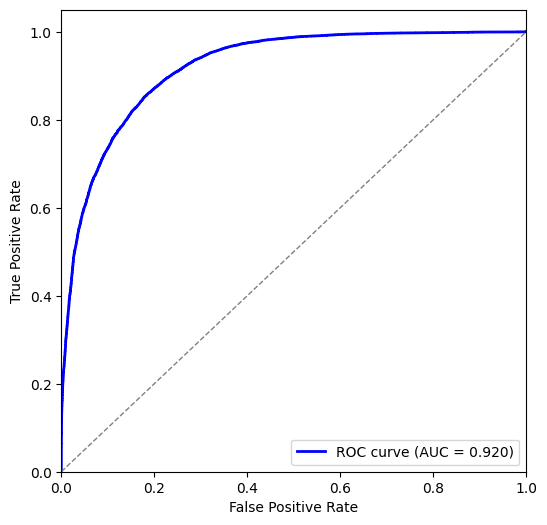

In [65]:
from splitfitter import plotROC

plotROC(sig2,bkg2,rw_model_basic)
plotROC(sig3,bkg3,rw_model_basic)

In [133]:
rw_model_basic_alt = simple_MLPFit_lmfit(dataset,10,k_fold=2,nhidden=64,out_channels=1,act_out=False,n_epochs=10,fit_opt=2,bkg_loss=0.1,iFitPFunc=fitGausBern(),iFitFFunc=fitGausBern(),
                                massDeco=0.,mc_data=mcdataset,bkgPressure=True,lambScale=0.0,batch_size=7020,lambvar=0.)

rw_model_basic_alt.pretrain(dataset3,5000,21)


Epoch: 0 LOSS train: 14.903352737426758 
Epoch: 10 LOSS train: 3.0537049770355225 
Epoch: 20 LOSS train: 2.7050085067749023 
Epoch: 0 LOSS train: 49.39805603027344 
Epoch: 10 LOSS train: 3.0100226402282715 
Epoch: 20 LOSS train: 2.574894666671753 


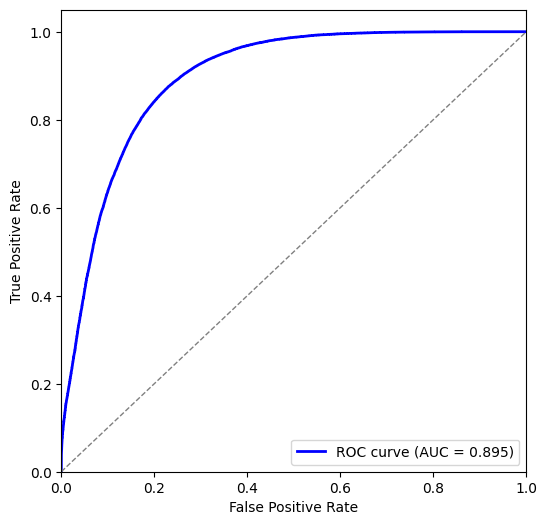

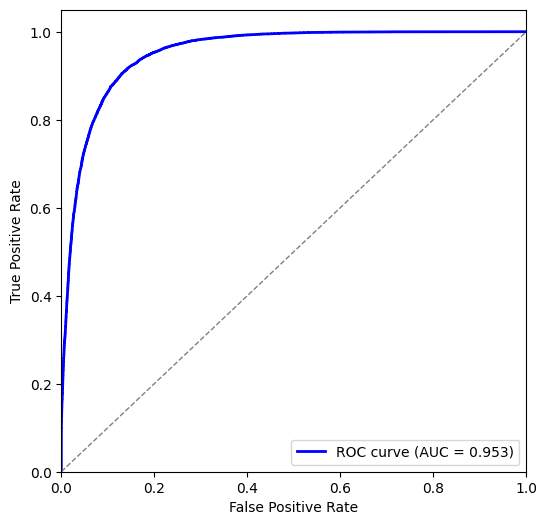

In [128]:
plotROC(sig2,bkg2,rw_model_basic_alt)
plotROC(sig3,bkg3,rw_model_basic_alt)

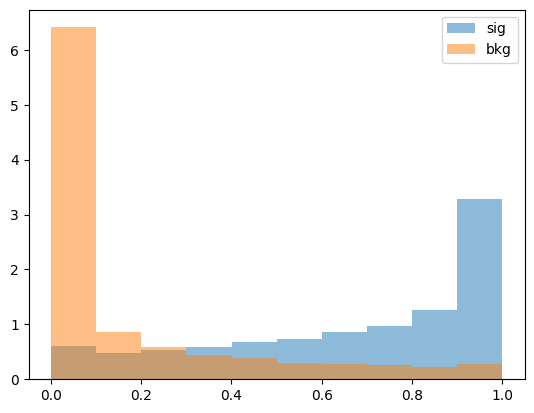

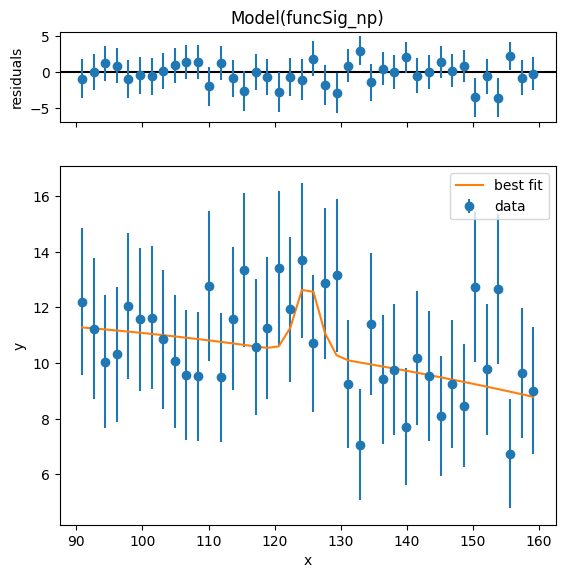

Pass Significance: 1.4137815992579785
Fail Significance: 0.00991310095335507


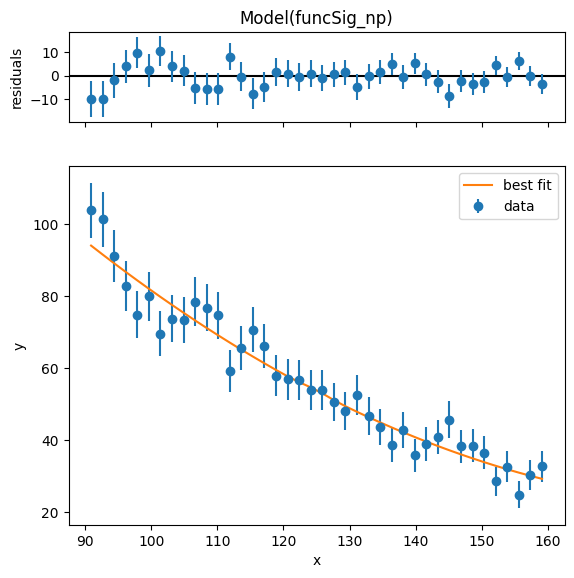

here!
torch.Size([50000, 1]) torch.Size([50000])
tensor([138.3898, 103.1991, 171.8703,  ...,  95.6697, 114.6748, 140.1557])
Bkg Significance: 0.24333500686175213


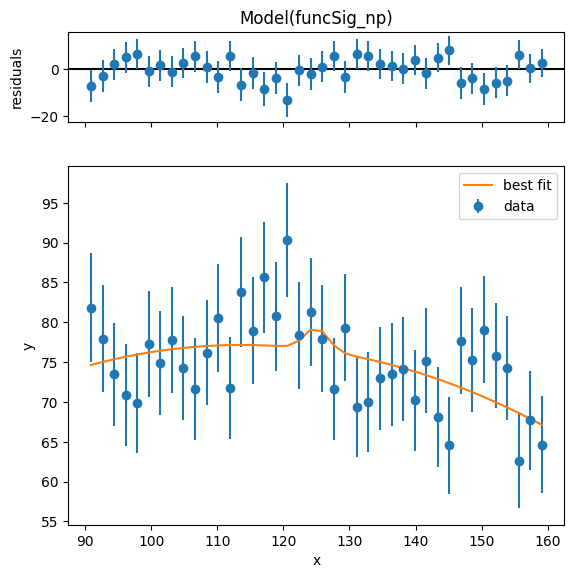

In [80]:
plotPerf(sig2,bkg2,rw_model_basic_alt,iNS=20,iNB=7000)

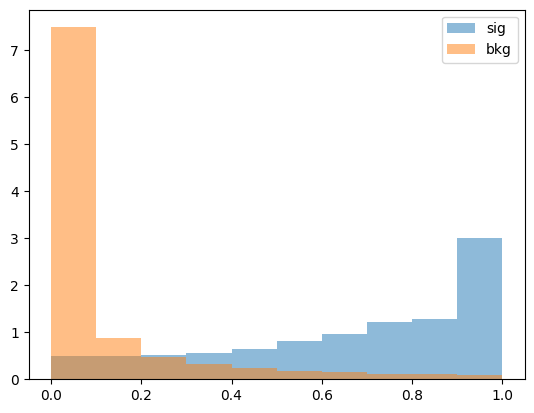

tensor([[1.3648e-01],
        [7.6058e-01],
        [9.5188e-01],
        ...,
        [1.1097e-03],
        [6.3018e-04],
        [7.2175e-02]], grad_fn=<CatBackward0>) tensor([[0.],
        [1.],
        [1.],
        ...,
        [0.],
        [0.],
        [0.]], grad_fn=<RoundBackward0>)


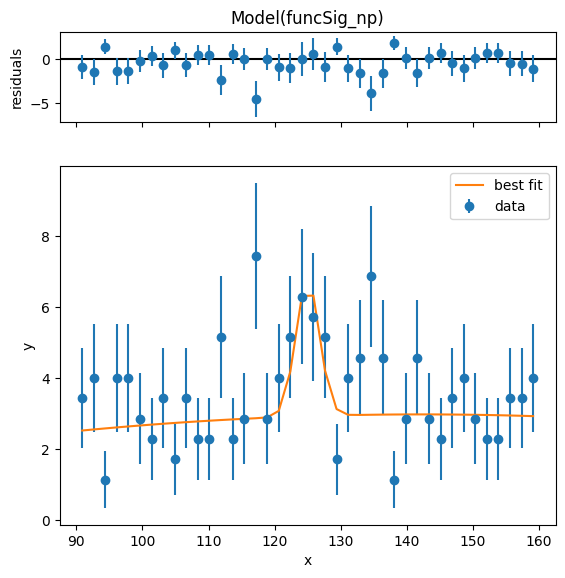

Pass Significance: 1.9009340137681008
Fail Significance: -3.5790037600236246e-11


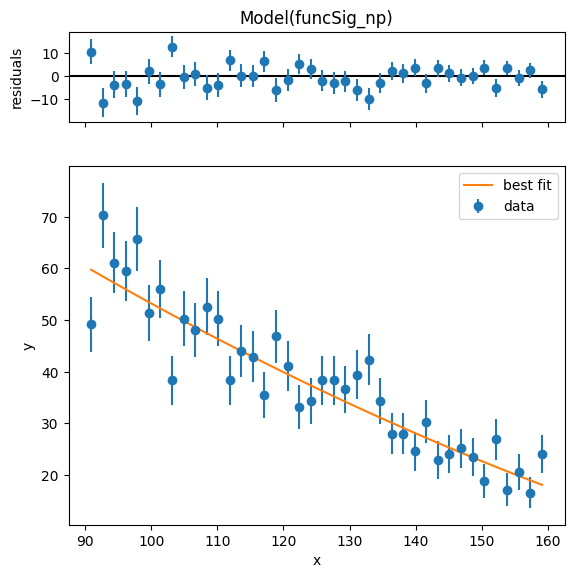

here!
torch.Size([20000, 1]) torch.Size([20000])
tensor([144.0136,  33.1916, 126.3021,  ..., 114.4022, 164.7717,  74.1269])
Bkg Significance: 0.697151339591354


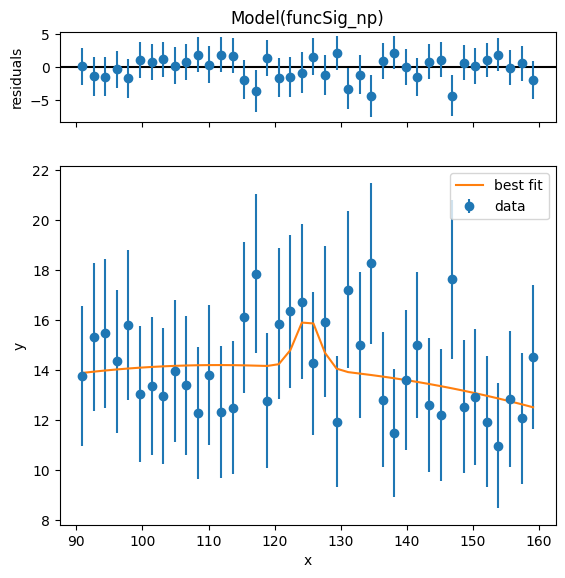

In [136]:
plotPerf(sig3,bkg3,rw_model_basic_alt,iNS=20,iNB=7000)

/Users/philipharris/Dropbox/Physics/8S50_2022/test2/CWOLAToy/splitfitter.py:1035: RuntimeWarning: invalid value encountered in sqrt
  lSigF=torch.sqrt(iModel.forward_sig(1.-output_disc,inputs.detach()))
/Users/philipharris/Dropbox/Physics/8S50_2022/test2/CWOLAToy/splitfitter.py:1037: RuntimeWarning: invalid value encountered in sqrt
  lBSig=torch.sqrt(iModel.forward_sig(obdisc,inputs_bkg.detach()))
/Users/philipharris/Dropbox/Physics/8S50_2022/test2/CWOLAToy/splitfitter.py:1034: RuntimeWarning: invalid value encountered in sqrt
  lSigP=torch.sqrt(iModel.forward_sig(output_disc,inputs.detach()))


Z-score: 2.5121443279304616 p-value: 0.006


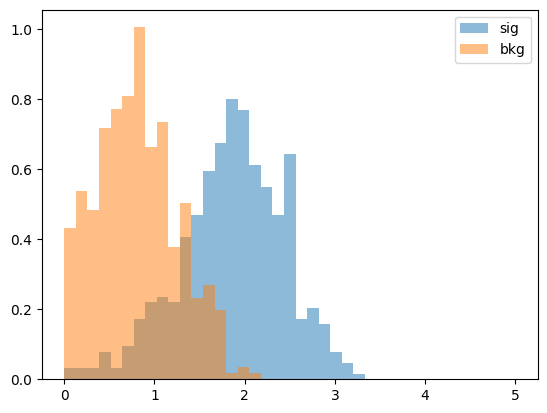

In [116]:
from splitfitter import plotPerfToys

plotPerfToys(sig3,bkg3,rw_model_basic_alt,iNS=20,iNB=7000)

Z-score: 1.1455050613926967 p-value: 0.126


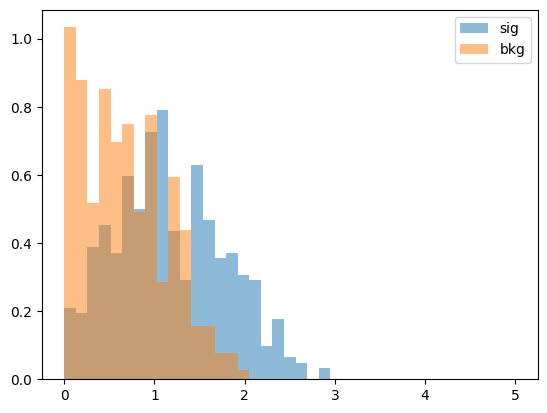

In [119]:
from splitfitter import plotPerfToys

plotPerfToys(sig2,bkg2,rw_model_basic_alt,iNS=20,iNB=7000)

In [198]:
rw_model_basic_alt = simple_MLPFit_lmfit(dataset,10,k_fold=1,nhidden=64,out_channels=1,act_out=False,n_epochs=10,fit_opt=2,bkg_loss=10.,iFitPFunc=fitGausBern(),iFitFFunc=fitGausBern(),
                                massDeco=0.,mc_data=mcdataset,bkgPressure=True,lambScale=0.0,batch_size=7020,lambvar=0.)


In [199]:
rw_model_basic_alt.pretrain(dataset2,5000,51)
rw_model_basic_alt.lambvar = 0.0
rw_model_basic_alt.bkg_loss = 1.0
rw_model_basic_alt.train(50)

Epoch: 0 LOSS train: 152.77394104003906 
Epoch: 10 LOSS train: 8.175980567932129 
Epoch: 20 LOSS train: 10.651659965515137 
Epoch: 30 LOSS train: 7.961154937744141 
Epoch: 40 LOSS train: 8.37406063079834 
Epoch: 50 LOSS train: 8.049359321594238 
K-fold 0
Epoch: 0 LOSS train: -1.6293549537658691 Pars 1: -2.277927718590929 - 2: 0.4809013331669334 deco: 0
Epoch: 1 LOSS train: 1.3975778818130493 Pars 1: 0 - 2: 1.2957392717361635 deco: 0
Epoch: 2 LOSS train: 1.4306058883666992 Pars 1: 0 - 2: 1.3297080734770645 deco: 0
Epoch: 3 LOSS train: 1.3075973987579346 Pars 1: 0 - 2: 1.2063362043791201 deco: 0
Epoch: 4 LOSS train: 1.185565710067749 Pars 1: 0 - 2: 1.0823100036366462 deco: 0
Epoch: 5 LOSS train: -0.5866148471832275 Pars 1: -1.5241143308578593 - 2: 0.81104793557882 deco: 0
Epoch: 6 LOSS train: -5.085582733154297 Pars 1: -5.6972607364566095 - 2: 0.4494220442120067 deco: 0
Epoch: 7 LOSS train: -3.9503087997436523 Pars 1: -4.499957971380564 - 2: 0.3374348102658189 deco: 0
Epoch: 8 LOSS train

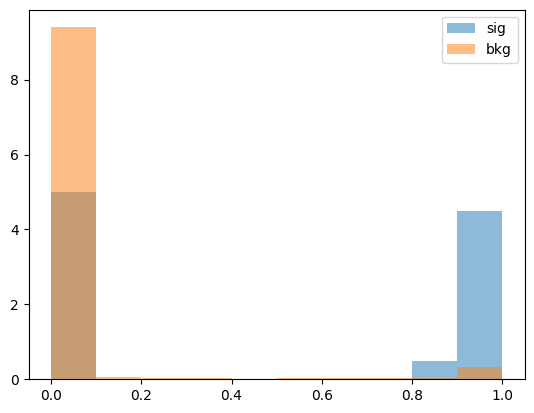

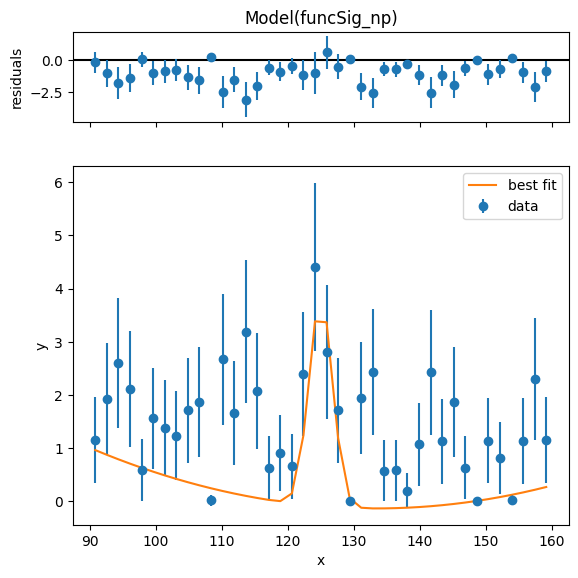

Pass Significance: 15.423622729836367
Fail Significance: 0.3596375030450929


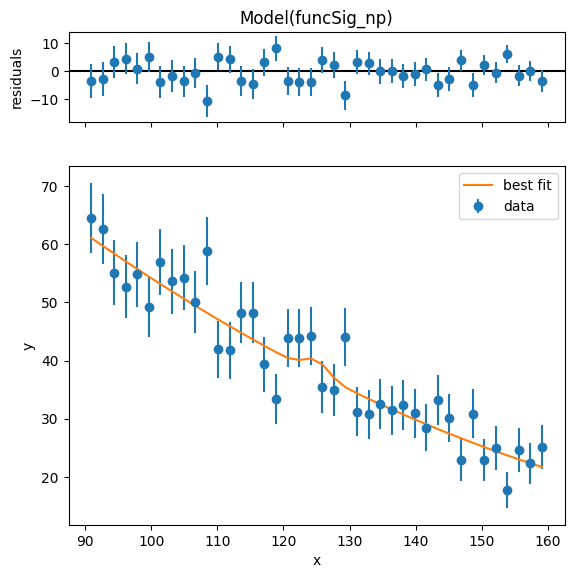

here!
torch.Size([7000, 1]) torch.Size([7000])
tensor([101.1338,  69.2160,  81.7647,  ...,  85.8496,  49.1674,  51.4697])
Bkg Significance: 4.983106982653894


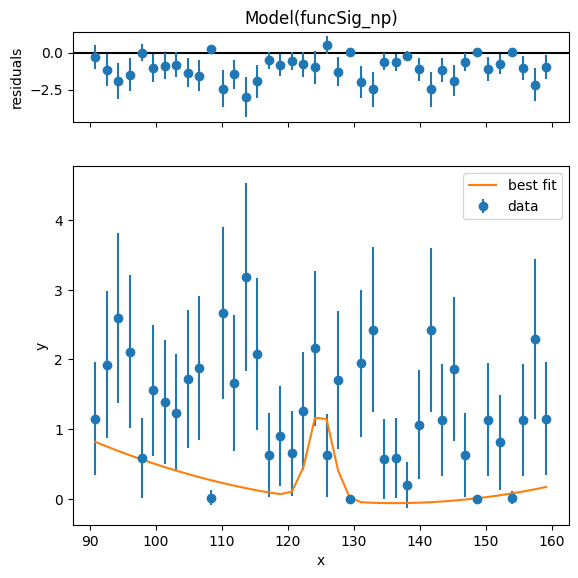

In [203]:
plotPerf(sig,bkg,rw_model_basic_alt)

Z-score: 0.892733324320856 p-value: 0.186


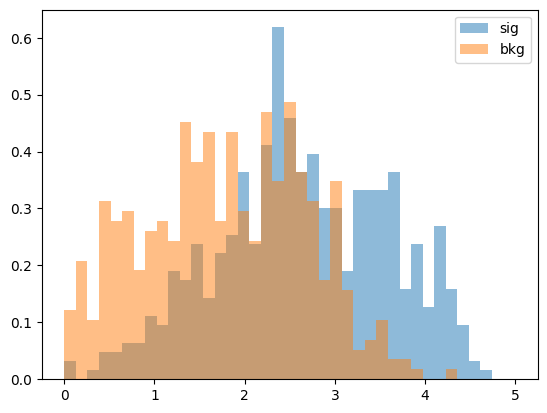

In [204]:
plotPerfToys(sig3,bkg3,rw_model_basic_alt,iNS=20,iNB=7000)

Z-score: 1.0278933458021426 p-value: 0.152


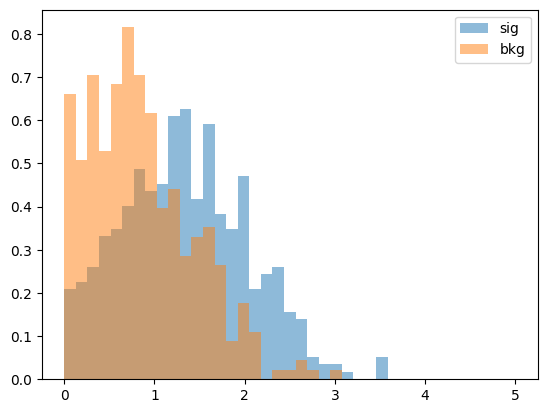

In [205]:
plotPerfToys(sig2,bkg2,rw_model_basic_alt,iNS=20,iNB=7000)